# Modeling a Galaxy with The Tractor

The Tractor (Lang et al. 2016) measures sources with a generative model. Given a parameterized
source model and an image model, meaning the point-spread function (PSF), the noise, the sky level,
and the photometric calibration, it computes the predicted image. The measurement is the set of
parameters that maximizes the likelihood of the data, which for independent Gaussian pixel noise is
the set that minimizes chi-squared.

Forced photometry follows from this construction. A model constrained in one
band is held fixed in position and morphology, then refitted for amplitude in the remaining bands.
Fluxes are therefore measured with a common source model across bands, including for sources that
are faint, blended, or formally undetected.

This notebook demonstrates how The Tractor works on a single source in a Q1 VIS image. The notebook
``01_multiband_forced_photometry.ipynb`` applies it to every source in a field and carries the
models measured in VIS into the NISP and unWISE bands.

## Imports

``RA`` and ``DEC`` are the coordinates of the target galaxy in degrees, and ``SIZE`` is the side of
the square cutout in arcsec. Installation, including the Tractor build, is described in the
[repository README](https://github.com/NimaChartab/euclid-forced-photometry).

In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import euclid_phot as ep
from tractor import (Image, PixelizedPSF, ConstantSky, LinearPhotoCal, NullWCS,
                     PixPos, Flux, EllipseE, ExpGalaxy, Tractor)

DATA_DIR = Path(os.environ.get("EUCLID_PHOT_DATA_DIR", "../examples/data"))
RA, DEC = 269.45284, 67.28963
SIZE = 6.0

## 1. Load the VIS cutout and its PSF

``fetch_cutout`` reads a ``SIZE`` arcsec box out of the MER VIS mosaic together with the matching
RMS map, which gives the noise in each pixel.

MER provides a PSF model evaluated at the position of every catalog source, the CATALOG-PSF
product. ``extract_catalog_psf`` returns the stamps around the target, and ``get_psf_for_source``
selects the one closest to the galaxy.

The cutout and the PSF stamps are downloaded from IRSA on first use and read from the local cache
afterwards.

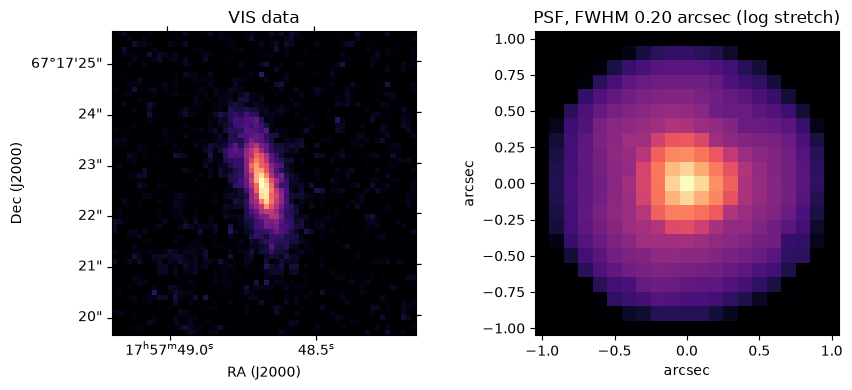

In [2]:
vis = ep.fetch_cutout("VIS", RA, DEC, SIZE, data_dir=DATA_DIR / "cutouts")
psf_data = ep.extract_catalog_psf("VIS", RA, DEC, data_dir=DATA_DIR / "psf")
psf, psf_fwhm, _ = ep.get_psf_for_source(psf_data, RA, DEC)

data = vis.data
invvar = 1.0 / vis.rms**2
x, y = vis.wcs.all_world2pix(RA, DEC, 0)

fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(1, 2, 1, projection=vis.wcs)
ax.imshow(data, origin="lower", cmap="magma", vmin=0, vmax=0.85 * data.max())
ax.set_title("VIS data")
ax.set_xlabel("RA (J2000)")
ax.set_ylabel("Dec (J2000)")
ax.coords[0].set_ticks(number=3)

psf_half = psf.shape[0] / 2 * vis.pixel_scale_arcsec
ax = fig.add_subplot(1, 2, 2)
ax.imshow(np.log10(np.clip(psf, 1e-5, None)), origin="lower", cmap="magma",
          extent=[-psf_half, psf_half, -psf_half, psf_half])
ax.set_title(f"PSF, FWHM {psf_fwhm:.2f} arcsec (log stretch)")
ax.set_xlabel("arcsec")
ax.set_ylabel("arcsec")
plt.tight_layout()
plt.show()

## 2. Construct the Tractor image and the source model

The fit is specified by three objects.

An ``Image`` contains the pixel data, the inverse variance, the PSF, the sky model, and the
photometric calibration. The calibration defines the relation between the fitted source flux and the
image units. The MER mosaic header records ``MAGZERO``, the AB magnitude corresponding to one image
unit of integrated flux. Since one microJansky has AB magnitude 23.9,
``10 ** (0.4 * (MAGZERO - 23.9))`` gives the number of image units per microJansky. Passing this
factor to ``LinearPhotoCal`` makes the fitted amplitude a flux in microJansky.

An ``ExpGalaxy`` is the source model. It is an exponential profile parameterized by position, flux,
and shape. The shape is stored as a half-light radius and two ellipticity components, equivalently
as an axis ratio and a position angle. The position is held fixed at the catalog coordinate, which
is the sense in which the photometry is forced. The remaining parameters are initialized away from
the expected solution, at 2 microJansky, circular, and compact.

The ``Tractor`` object combines the image and the source model and performs the optimization.

In [3]:
counts_per_ujy = 10 ** (0.4 * (vis.header["MAGZERO"] - 23.9))
tim = Image(data=data, invvar=invvar, psf=PixelizedPSF(psf),
            wcs=NullWCS(pixscale=vis.pixel_scale_arcsec),
            sky=ConstantSky(0.0), photocal=LinearPhotoCal(counts_per_ujy))

gal = ExpGalaxy(PixPos(float(x), float(y)), Flux(2.0), EllipseE.fromRAbPhi(0.15, 1.0, 0.0))
gal.freezeParam("pos")

tractor = Tractor([tim], [gal])
tractor.freezeParam("images")

## 3. Optimize the model against the pixels

Each call to ``optimize`` performs one step. The Tractor computes the derivative of the predicted
image with respect to each free parameter, solves the resulting linear least-squares problem for the
direction that most reduces chi-squared, evaluates a set of step lengths along that direction, and
retains the best step. Four parameters vary here: the flux and the three shape parameters.

A single call to ``tractor.optimize_loop()`` would iterate to convergence. The loop is written out
below so that the parameters can be printed after every step. It terminates on the same criterion,
when the gain in log-likelihood falls below a threshold. In this example that occurs after seven
steps.

In [4]:
for step in range(30):
    dlnp, _, _ = tractor.optimize()
    print(f"step {step + 1}: flux {gal.brightness.getValue():.2f} uJy, "
          f"re {gal.shape.re:.2f} arcsec, b/a {gal.shape.ab:.2f}")
    if dlnp < 1e-3:
        break

step 1: flux 2.05 uJy, re 0.44 arcsec, b/a 0.11
step 2: flux 2.72 uJy, re 0.73 arcsec, b/a 0.33
step 3: flux 4.07 uJy, re 0.98 arcsec, b/a 0.27
step 4: flux 4.08 uJy, re 0.91 arcsec, b/a 0.30
step 5: flux 4.10 uJy, re 0.92 arcsec, b/a 0.30
step 6: flux 4.10 uJy, re 0.92 arcsec, b/a 0.30
step 7: flux 4.10 uJy, re 0.92 arcsec, b/a 0.30


## 4. Data, model, and residual

The third panel is the chi image: the residual, data minus model, divided by the noise sigma of each
pixel. This is the quantity returned by ``Tractor.getChiImage``, and its sum of squares is the
chi-squared minimized by the fit. A converged fit leaves a chi image consistent with pixel noise,
with no coherent residual structure at the source position.

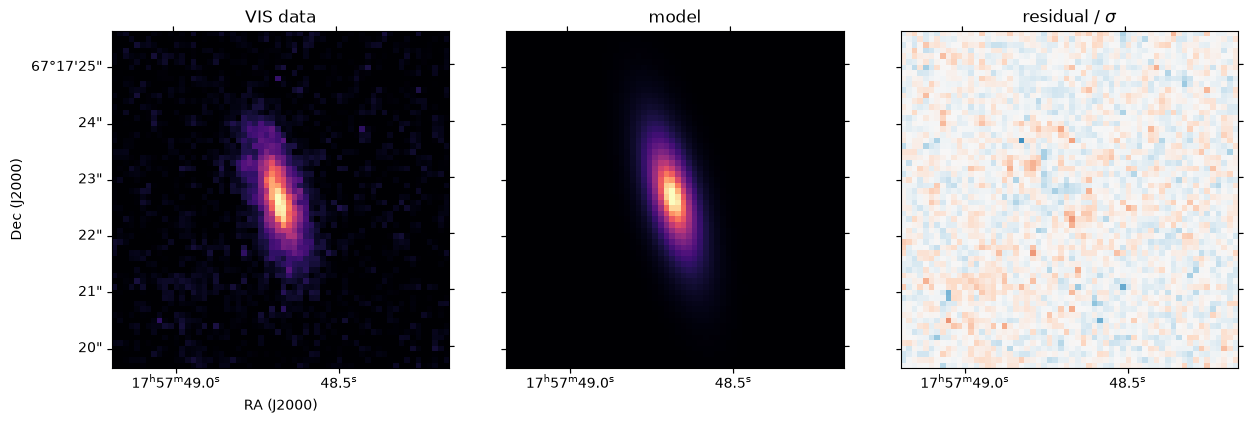

In [5]:
model = tractor.getModelImage(0)
chi = (data - model) * np.sqrt(invvar)

panels = [(data, "VIS data", dict(cmap="magma", vmin=0, vmax=0.85 * data.max())),
          (model, "model", dict(cmap="magma", vmin=0, vmax=0.85 * data.max())),
          (chi, r"residual / $\sigma$", dict(cmap="RdBu_r", vmin=-6, vmax=6))]

fig = plt.figure(figsize=(13, 4.2))
for k, (img, title, kw) in enumerate(panels):
    ax = fig.add_subplot(1, 3, k + 1, projection=vis.wcs)
    ax.imshow(img, origin="lower", **kw)
    ax.set_title(title)
    ax.coords[0].set_ticks(number=3)
    if k == 0:
        ax.set_xlabel("RA (J2000)")
        ax.set_ylabel("Dec (J2000)")
    else:
        ax.coords[0].set_axislabel("")
        ax.coords[1].set_axislabel("")
        ax.coords[1].set_ticklabel_visible(False)
plt.tight_layout()
plt.show()